# 01 - UNSW_NB15 data exploration


This notebook explores the dataset.

**Main goals :**
1. Load and understand data structure.
2. Analyze distributions.
3. Identify potential issues (eg : missing values).
4. Adress class imbalance. 

## 0 - Imports and configuration

In [1]:
#Imports

import sys
sys.path.append('../src')

In [2]:
#Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from data_loader import load_unsw_data, get_feature_types, get_data_summary

# Plot configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

print("All good!")

All good!


## 1 - Data loading

In [3]:
df_train = load_unsw_data(data_dir = '../data/archive', dataset = 'training')
df_test = load_unsw_data(data_dir = '../data/archive', dataset = 'testing')

print("\n")

print(f"Training set: {df_train.shape}")
print(f"Testing set:  {df_test.shape}")


Loading ../data/archive/UNSW_NB15_training-set.parquet...
Loaded 175341 rows and 36 columns.
Loading ../data/archive/UNSW_NB15_testing-set.parquet...
Loaded 82332 rows and 36 columns.


Training set: (175341, 36)
Testing set:  (82332, 36)


## 2 - Data overview

In [4]:
display(df_train.head()) #display() creates a cleaner preview than print().

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,8495.365234,0,0,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,503571.312500,2,17,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,60929.230469,1,6,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,3358.622070,1,3,152.876541,90.235725,259.080170,4991.784668,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,3987.059814,2,1,47.750332,75.659599,2415.837646,115.806999,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,2,1,0,0,0,0,Normal,0


In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-null  float32 


In [6]:
display(df_train.describe())

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,95406.179688,7.345403e+07,6.712056e+05,4.953000,6.948010,985.976929,88.216301,4.976254e+03,604.353821,116.257339,9.692504e+08,9.688770e+08,115.013625,0.041396,0.021020,0.020375,136.751769,124.173382,0.105982,2.144292e+03,5.383538,4.206255,0.014948,0.014948,0.133066,0.015752,0.680622
std,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,165400.968750,1.883574e+08,2.421312e+06,66.005059,52.732999,7242.245605,987.093201,4.496585e+04,4061.043213,127.001024,1.355264e+09,1.354000e+09,126.886530,0.079354,0.043400,0.040506,204.677360,258.317056,0.776911,5.420797e+04,8.047104,5.783585,0.126048,0.126048,0.701208,0.124516,0.466237
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,32.786140,1.305334e+04,0.000000e+00,0.000000,0.000000,0.008000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3225.806641,8.796748e+05,1.447023e+03,0.000000,0.000000,0.279733,0.006000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,73.000000,44.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,125000.000000,8.888889e+07,2.784487e+04,3.000000,2.000000,55.156895,51.053001,2.513295e+03,114.990623,255.000000,1.916651e+09,1.913675e+09,255.000000,0.065481,0.023268,0.038906,100.000000,89.000000,0.000000,0.000000e+00,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1000000.000000,5.988000e+09,2.242273e+07,4803.000000,5484.000000,84371.492188,56716.824219,1.460480e+06,289388.281250,255.000000,4.294959e+09,4.294882e+09,255.000000,2.518893,2.100352,1.520884,1504.000000,1458.000000,172.000000,6.558056e+06,51.000000,46.000000,4.000000,4.000000,30.000000,1.000000,1.000000


## 3 - Data summary

In [7]:
summary_train = get_data_summary(df_train)
summary_test = get_data_summary(df_test) 

print("Training Set :")
for key, value in summary_train.items():
    print(f"  {key:20s}: {value}")

print("="*60)

print("Testing Set :")
for key, value in summary_test.items():
    print(f"  {key:20s}: {value}")  

Training Set :
  n_samples           : 175341
  n_features          : 36
  memory_usage        : 17.05837631225586
  missing_values      : 0
  duplicate_rows      : 78519
Testing Set :
  n_samples           : 82332
  n_features          : 36
  memory_usage        : 8.010904312133789
  missing_values      : 0
  duplicate_rows      : 32361


## 4 - Feature types

In [8]:
feature_types = get_feature_types(df_train)

print(f"\n Features numériques ({len(feature_types['numerical'])}):")
for feat in feature_types['numerical'][:10]:  # Afficher les 10 premières
    print(f"  : {feat}")

if len(feature_types['numerical']) > 10:
    print(f"  ... et {len(feature_types['numerical']) - 10} autres\n")


 Features numériques (32):
  : dur
  : spkts
  : dpkts
  : sbytes
  : dbytes
  : rate
  : sload
  : dload
  : sloss
  : dloss
  ... et 22 autres



In [9]:
print(f"\n Categorical features ({len(feature_types['categorical'])}):")
for feat in feature_types['categorical']:
    print(f"  - {feat}")


 Categorical features (4):
  - proto
  - service
  - state
  - attack_cat


## 5 - Target variable analysis

In [10]:
label_columns = [col for col in df_train.columns if 'label' in col.lower() or 'attack' in col.lower()]
print(f"\nColumns linked with labels: {label_columns}")


Columns linked with labels: ['attack_cat', 'label']


In [11]:
label_columns = [col for col in df_train.columns if 'label' in col.lower() or 'attack' in col.lower()]
print(f"\nColumns linked with labels : {label_columns}")

if 'label' in df_train.columns :
    print("\nClass distribution - Training Set :")
    train_distribution = df_train['label'].value_counts().sort_index()
    print(train_distribution)
    print(f"  Normal : {train_distribution[0] :,} ({train_distribution[0]/len(df_train)*100 :.2f}%)")
    print(f"  Attack : {train_distribution[1] :,} ({train_distribution[1]/len(df_train)*100 :.2f}%)")
    
    print("\nClass distribution - Testing Set :")
    test_distribution = df_test['label'].value_counts().sort_index()
    print(test_distribution)
    print(f"  Normal : {test_distribution[0] :,} ({test_distribution[0]/len(df_test)*100 :.2f}%)")
    print(f"  Attack : {test_distribution[1] :,} ({test_distribution[1]/len(df_test)*100 :.2f}%)")


Columns linked with labels : ['attack_cat', 'label']

Class distribution - Training Set :
label
0     56000
1    119341
Name: count, dtype: int64
  Normal : 56,000 (31.94%)
  Attack : 119,341 (68.06%)

Class distribution - Testing Set :
label
0    37000
1    45332
Name: count, dtype: int64
  Normal : 37,000 (44.94%)
  Attack : 45,332 (55.06%)


## 6 - Class distribution visualization

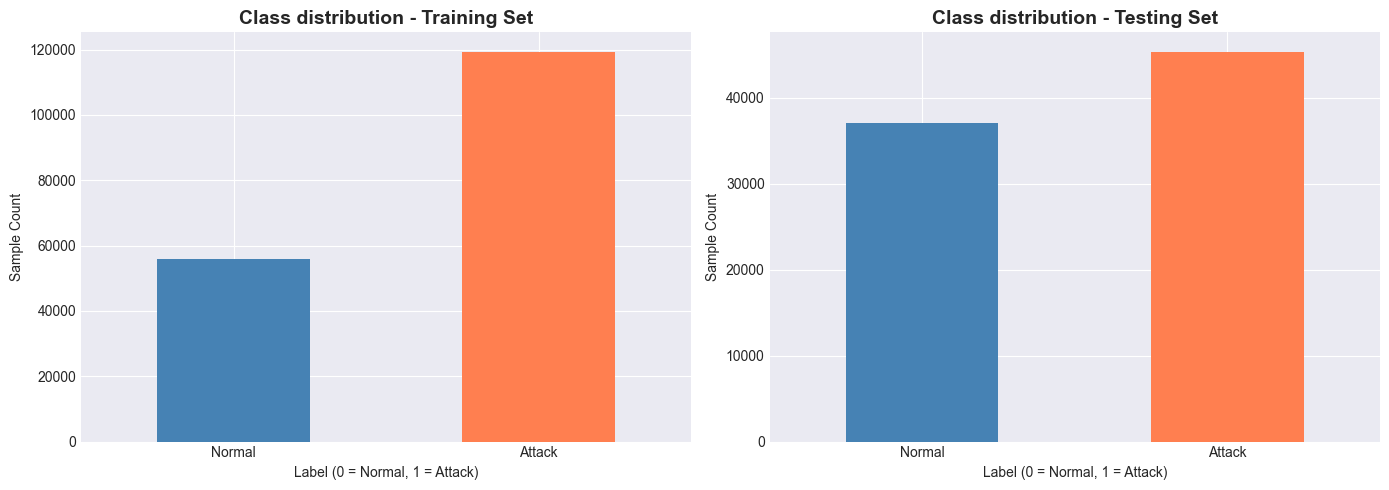

In [12]:
if 'label' in df_train.columns :
    fig, axes = plt.subplots(1, 2, figsize = (14, 5))
    # Training set
    train_dist = df_train['label'].value_counts().sort_index()
    train_dist.plot(kind = 'bar', ax = axes[0], color = ['steelblue', 'coral'])
    axes[0].set_title('Class distribution - Training Set', fontsize = 14, fontweight = 'bold')
    axes[0].set_xlabel('Label (0 = Normal, 1 = Attack)')
    axes[0].set_ylabel('Sample Count')
    axes[0].set_xticklabels(['Normal', 'Attack'], rotation = 0)
    # Testing set
    test_dist = df_test['label'].value_counts().sort_index()
    test_dist.plot(kind = 'bar', ax = axes[1], color = ['steelblue', 'coral'])
    axes[1].set_title('Class distribution - Testing Set', fontsize = 14, fontweight = 'bold')
    axes[1].set_xlabel('Label (0 = Normal, 1 = Attack)')
    axes[1].set_ylabel('Sample Count')
    axes[1].set_xticklabels(['Normal', 'Attack'], rotation = 0)
    plt.tight_layout()
    plt.savefig('../results/figures/class_distribution.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

## 7 - Attack types analysis

In [13]:
#Attack type distrib

if 'attack_cat' in df_train.columns:
  print("\nAttack type distribution - Training Set:")
  print("="*60)
  print(df_train['attack_cat'].value_counts())
  print("\n")
  print("\nAttack type distribution - Testing Set:")
  print("="*60)
  print(df_test['attack_cat'].value_counts())


Attack type distribution - Training Set:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64



Attack type distribution - Testing Set:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


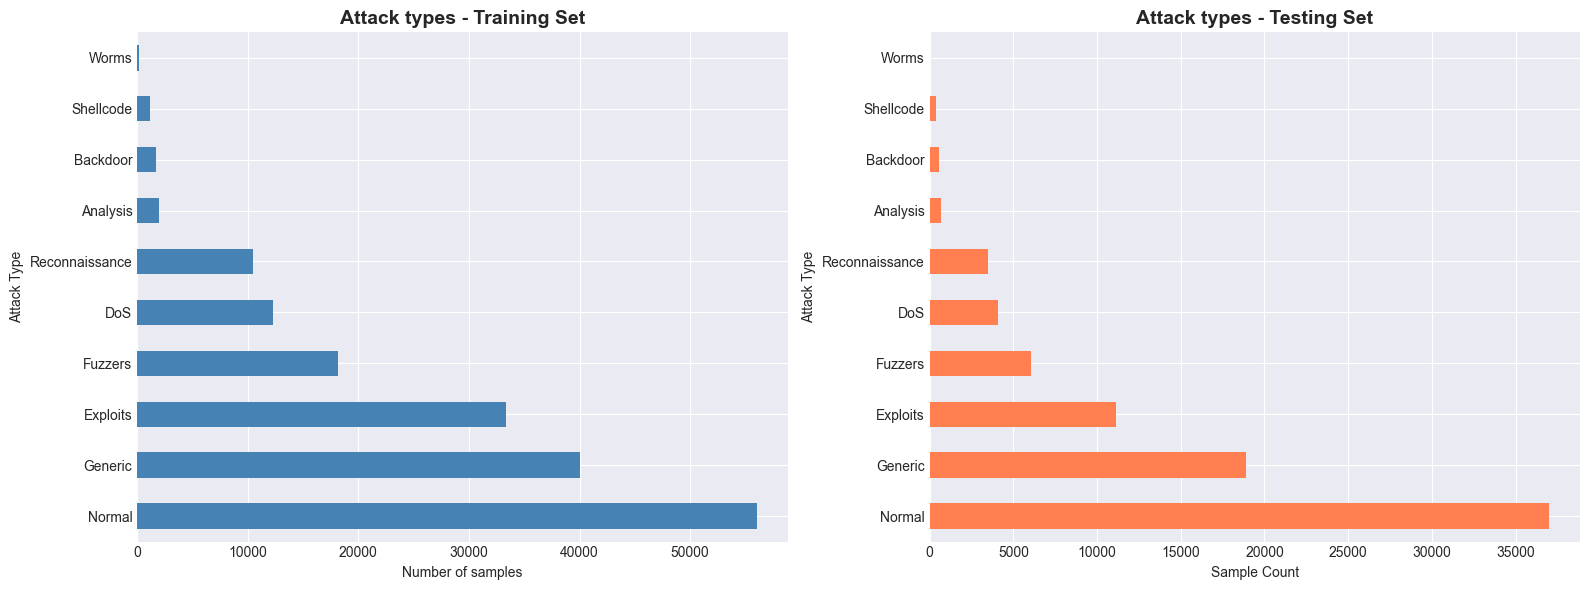

In [14]:
#Attack types distribution visualization

if 'attack_cat' in df_train.columns:
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))
  df_train['attack_cat'].value_counts().plot(kind = 'barh',  ax = axes[0], color = 'steelblue')
  axes[0].set_title('Attack types - Training Set', fontsize=14, fontweight='bold')
  axes[0].set_xlabel('Number of samples')
  axes[0].set_ylabel('Attack Type')

  df_test['attack_cat'].value_counts().plot(kind = 'barh',  ax = axes[1], color = 'coral')
  axes[1].set_title('Attack types - Testing Set', fontsize=14, fontweight='bold')
  axes[1].set_xlabel('Sample Count')
  axes[1].set_ylabel('Attack Type')

  plt.tight_layout()
  plt.savefig('../results/figures/attack_types.png', dpi = 300, bbox_inches = 'tight')
  plt.show()

## 8 - Potential missing values analysis

In [15]:
missing_train = df_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_test = df_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

if len(missing_train) > 0:
    print("\nTraining Set - Columns with missing values:")
    for col, count in missing_train.items():
        percentage = (count / len(df_train)) * 100
        print(f"  {col:30s}: {count:6d} ({percentage:5.2f}%)")
else:
    print("No missing values in training set.")

print("\n" + "&" + "\n")

if len(missing_test) > 0:
    print("\nTesting Set - Columns with missing values:")
    for col, count in missing_test.items():
        percentage = (count / len(df_test)) * 100
        print(f"  {col:30s}: {count:6d} ({percentage:5.2f}%)")
else:
    print("No missing values in testing set.")


No missing values in training set.

&

No missing values in testing set.


## 9 - Correlation analysis

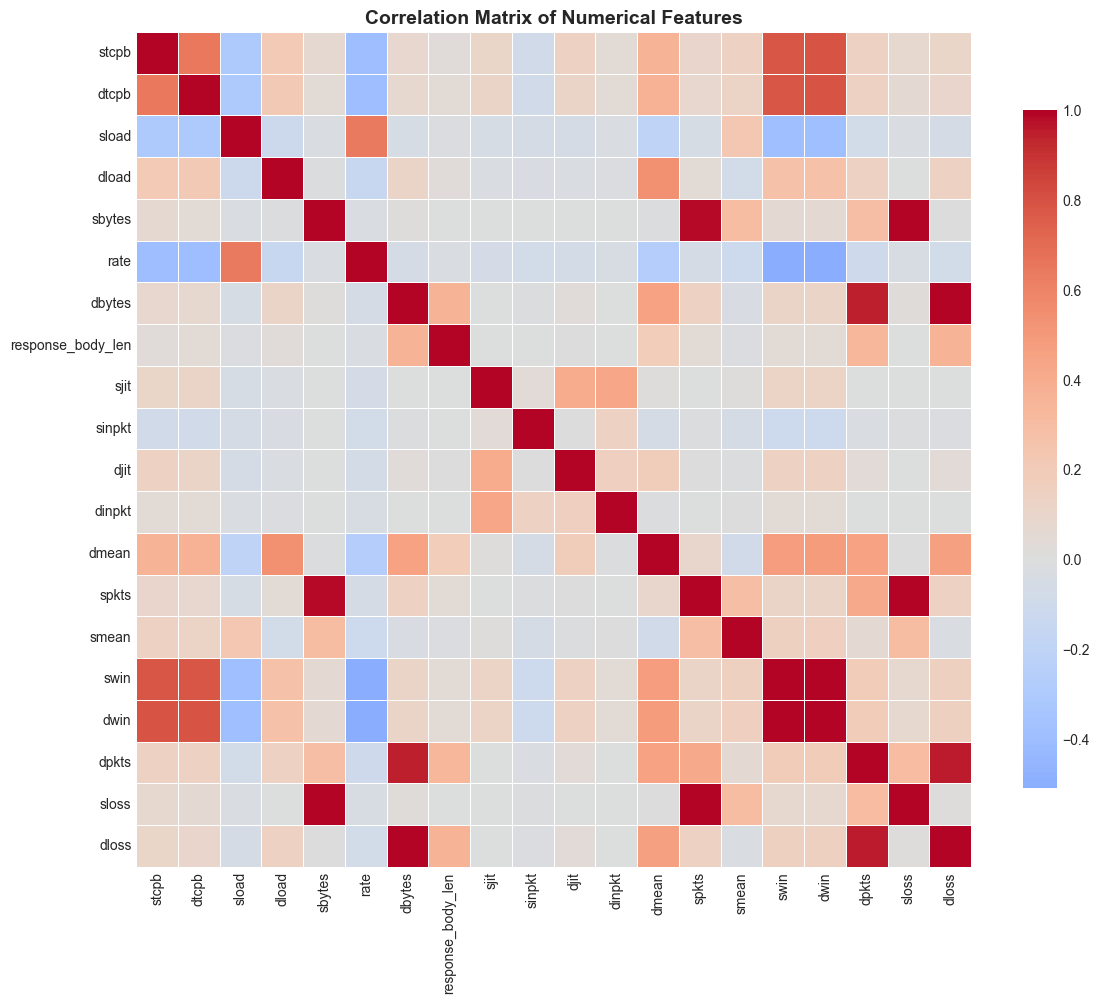

In [16]:
numerical_cols = feature_types['numerical'].copy()
if 'label' in numerical_cols:
  numerical_cols.remove('label')  #Will remove 'label' if it's in the list of numerical features.

sample_size = min(5000, len(df_train)) #If the dataset is smaller than 5000, we take the whole dataset.
df_sample = df_train[numerical_cols].sample(n=sample_size, random_state=42) #Random sample of 5000 rows. 
correlation_matrix = df_sample.corr()

if len(numerical_cols) > 20:
  top_features = df_sample.var().nlargest(20).index.tolist() # Select features with highest variance
  correlation_matrix = df_sample[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot = False, cmap = 'coolwarm', center = 0, square = True, linewidths = 0.5, cbar_kws = {"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../results/figures/correlation_matrix.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [17]:
#Highly correlated features :

correlation_matrix_full = df_train[numerical_cols].corr()

high_corr = []
for i in range(len(correlation_matrix_full.columns)):
    for j in range(i+1, len(correlation_matrix_full.columns)): #i + 1 to avoid double checking.
        if abs(correlation_matrix_full.iloc[i, j]) > 0.9:
            high_corr.append((
                correlation_matrix_full.columns[i],
                correlation_matrix_full.columns[j],
                correlation_matrix_full.iloc[i, j]
            ))

if high_corr:
    print("Possibly redudant features :")
    for feat1, feat2, corr in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("No very high correlations detected")

Possibly redudant features :
  is_ftp_login <-> ct_ftp_cmd: 1.000
  dbytes <-> dloss: 0.997
  sbytes <-> sloss: 0.996
  swin <-> dwin: 0.990
  dpkts <-> dloss: 0.979
  dpkts <-> dbytes: 0.972
  spkts <-> sloss: 0.971
  spkts <-> sbytes: 0.964
  tcprtt <-> synack: 0.949
  tcprtt <-> ackdat: 0.942
  sinpkt <-> is_sm_ips_ports: 0.941
  ct_src_dport_ltm <-> ct_dst_sport_ltm: 0.907


## 10 - Summary & Conclusions

In [18]:
print("Summary :")

print("\n1. Data size :")
print(f"- Training : {df_train.shape[0] :,} samples, {df_train.shape[1]} features")
print(f"- Testing :  {df_test.shape[0] :,} samples, {df_test.shape[1]} features")

print("\n2. Feature types :")
print(f"- Numerical : {len(feature_types['numerical'])}")
print(f"- Categorical : {len(feature_types['categorical'])}")

if 'label' in df_train.columns :
    train_normal = (df_train['label'] == 0).sum()
    train_attack = (df_train['label'] == 1).sum()
    test_normal = (df_test['label'] == 0).sum()
    test_attack = (df_test['label'] == 1).sum()
    
    print("\n3. Class distribution : Training :")
    print(f"- Normal : {train_normal :,} ({train_normal/len(df_train)*100 :.2f}%)")
    print(f"- Attack : {train_attack :,} ({train_attack/len(df_train)*100 :.2f}%)")
    
    print("\n4. Class distribution : Testing :")
    print(f"- Normal : {test_normal :,} ({test_normal/len(df_test)*100 :.2f}%)")
    print(f"- Attack : {test_attack :,} ({test_attack/len(df_test)*100 :.2f}%)")

if len(missing_train) > 0 :
    print("\n5. Missing values :")
    print(f"- {len(missing_train)} columns with missing values")
    print("Preprocessing required.")
else :
    print("\n5. Missing values :")
    print("No missing values detected.")

if len(high_corr) > 0 :
    print("\n6. Correlations :")
    print(f"- {len(high_corr)} pairs of highly correlated features (|r| > 0.9)")
    print("Potential dimensionality reduction")
else :
    print("\n6. Correlations :")
    print("No excessive correlations detected.")

Summary :

1. Data size :
- Training : 175,341 samples, 36 features
- Testing :  82,332 samples, 36 features

2. Feature types :
- Numerical : 32
- Categorical : 4

3. Class distribution : Training :
- Normal : 56,000 (31.94%)
- Attack : 119,341 (68.06%)

4. Class distribution : Testing :
- Normal : 37,000 (44.94%)
- Attack : 45,332 (55.06%)

5. Missing values :
No missing values detected.

6. Correlations :
- 12 pairs of highly correlated features (|r| > 0.9)
Potential dimensionality reduction
